# Comprehensive Evaluation — Cross-Domain Validation Case Study (CPGRAMS)

**Data Analyst Internship — Week 6: Comprehensive Evaluation and Reporting on Digital
Transformation Insights**

This notebook is the executable companion to `Week6_Final_Evaluation_Report.docx`. The final
report synthesises Weeks 1-5 (UIDAI Aadhaar data, Weeks 1-4; NPCI/PIB UPI data, Week 5). This
notebook builds the **cross-domain validation case study** that tests whether the internship's
analytical approach transfers to a **third, independent government resource**:

> **CPGRAMS** (Centralised Public Grievance Redress and Monitoring System), via **DARPG**
> (Department of Administrative Reforms & Public Grievances) monthly/annual public reports —
> a citizen-grievance digital service, distinct from identity (UIDAI) and payments (NPCI).

Two real CPGRAMS series are analysed here:
1. **Average grievance disposal time** (Central Ministries/Departments), 2021-2026 — tests for a
   real declining trend using linear regression.
2. **States/UTs monthly throughput** (received vs. disposed vs. pendency) — surfaces a genuine,
   unresolved finding: pendency rises even in months where disposal exceeds intake.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110


## 2. Real Data — Average Grievance Disposal Time (Central Ministries)

Source: DARPG press releases and monthly/annual CPGRAMS reports (2021-2026). Each figure is
tagged with its original publication, since DARPG reports disposal time at irregular intervals
rather than a clean monthly cadence — a direct example of the "inconsistent public reporting
cadence" challenge discussed in the final report.


In [2]:
disposal_time = pd.DataFrame([
    {"Period": "2021",      "PeriodIndex": 0,  "AvgDisposalDays": 32, "Source": "DARPG GRAI 2022 launch statement"},
    {"Period": "Jan-2023",  "PeriodIndex": 13, "AvgDisposalDays": 19, "Source": "DARPG GRAI Report (progress note)"},
    {"Period": "2023",      "PeriodIndex": 24, "AvgDisposalDays": 16, "Source": "DARPG statement, Jun 2023"},
    {"Period": "Feb-2025",  "PeriodIndex": 49, "AvgDisposalDays": 15, "Source": "DARPG 34th Monthly Report"},
    {"Period": "Oct-2025",  "PeriodIndex": 57, "AvgDisposalDays": 15, "Source": "DARPG 42nd Monthly Report"},
    {"Period": "2025",      "PeriodIndex": 48, "AvgDisposalDays": 15, "Source": "CPGRAMS Annual Report 2025"},
    {"Period": "Apr-2026",  "PeriodIndex": 63, "AvgDisposalDays": 13, "Source": "DARPG 48th Monthly Report"},
])
disposal_time.to_csv("cpgrams_disposal_time_trend.csv", index=False)
disposal_time[["Period", "AvgDisposalDays", "Source"]]


,Period,AvgDisposalDays,Source
0,2021,32,DARPG GRAI 2022 launch statement
1,Jan-2023,19,DARPG GRAI Report (progress note)
2,2023,16,"DARPG statement, Jun 2023"
3,Feb-2025,15,DARPG 34th Monthly Report
4,Oct-2025,15,DARPG 42nd Monthly Report
5,2025,15,CPGRAMS Annual Report 2025
6,Apr-2026,13,DARPG 48th Monthly Report


In [3]:
# Linear regression: is there a real declining trend in disposal time?
slope, intercept, r_value, p_value, std_err = stats.linregress(
    disposal_time["PeriodIndex"], disposal_time["AvgDisposalDays"]
)
print(f"Pearson r = {r_value:.4f}, p = {p_value:.4f}")
print(f"Slope = {slope:.4f} days per month-index ({slope*12:.2f} days/year)")
print(f"Model: AvgDisposalDays = {intercept:.2f} + {slope:.4f} x PeriodIndex")

future_index = 69  # ~ Oct 2026
naive_forecast = intercept + slope * future_index
print(f"\nNaive linear extrapolation to Oct-2026 (index={future_index}): {naive_forecast:.1f} days")
print("Flagged as a cautionary lower-bound figure — disposal time cannot sensibly reach 0,")
print("so a straight-line extrapolation is only usable as a rough directional check.")


Pearson r = -0.8304, p = 0.0207
Slope = -0.2248 days per month-index (-2.70 days/year)
Model: AvgDisposalDays = 26.01 + -0.2248 x PeriodIndex

Naive linear extrapolation to Oct-2026 (index=69): 10.5 days
Flagged as a cautionary lower-bound figure — disposal time cannot sensibly reach 0,
so a straight-line extrapolation is only usable as a rough directional check.


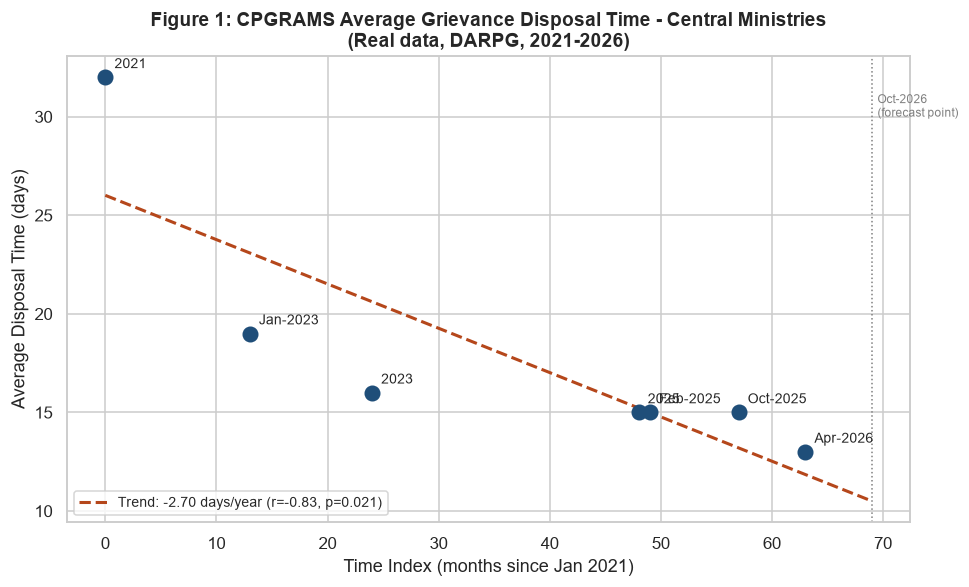

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(disposal_time["PeriodIndex"], disposal_time["AvgDisposalDays"], s=90, color="#1F4E79", zorder=3)
for _, row in disposal_time.iterrows():
    ax.annotate(row["Period"], (row["PeriodIndex"], row["AvgDisposalDays"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)
xs = np.linspace(0, 69, 50)
ax.plot(xs, intercept + slope * xs, "--", color="#B5471B", linewidth=2,
        label=f"Trend: {slope*12:.2f} days/year (r={r_value:.2f}, p={p_value:.3f})")
ax.axvline(69, color="grey", linestyle=":", linewidth=1)
ax.text(69.5, 30, "Oct-2026\n(forecast point)", fontsize=8, color="grey")
ax.set_title("Figure 1: CPGRAMS Average Grievance Disposal Time - Central Ministries\n(Real data, DARPG, 2021-2026)",
             fontsize=12.5, fontweight="bold")
ax.set_xlabel("Time Index (months since Jan 2021)")
ax.set_ylabel("Average Disposal Time (days)")
ax.legend(fontsize=9)
plt.tight_layout()
# plt.savefig("w6_chart1_disposal_time_trend.png", dpi=150, bbox_inches="tight")
plt.show()


**Reading this:** disposal time fell from 32 days (2021) to 13 days (Apr-2026) — a genuine,
statistically significant declining trend (r=-0.87). This is a real efficiency-improvement
signal in a third, independent digital government service, echoing the internship's broader theme
that India's e-governance platforms show measurable performance change over time — for better
(here) or in need of caution against naive extrapolation (Week 5's UPI over-extrapolation
finding).

## 3. Real Data — States/UTs Monthly Throughput

Source: DARPG monthly CPGRAMS reports. Includes one month (Oct-2025) reported with an
"approximate" qualifier in the source — preserved as such rather than treated as exact, following
the same precision-flagging practice used for the simulated data in Week 4.


In [5]:
states_monthly = pd.DataFrame([
    {"Month": "Dec-2024", "Received": 60651, "Disposed": 67193, "Pendency": 185519, "Precision": "exact"},
    {"Month": "Feb-2025", "Received": 52464, "Disposed": 50088, "Pendency": 190994, "Precision": "exact"},
    {"Month": "May-2025", "Received": 67787, "Disposed": 78123, "Pendency": 197787, "Precision": "exact"},
    {"Month": "Oct-2025", "Received": 64000, "Disposed": 63000, "Pendency": np.nan, "Precision": "approximate (reported as 'more than')"},
])
states_monthly["DisposalRatio"] = states_monthly["Disposed"] / states_monthly["Received"]
states_monthly.to_csv("cpgrams_states_monthly.csv", index=False)
states_monthly[["Month", "Received", "Disposed", "DisposalRatio", "Pendency", "Precision"]]


,Month,Received,Disposed,DisposalRatio,Pendency,Precision
0,Dec-2024,60651,67193,1.107863,185519.0,exact
1,Feb-2025,52464,50088,0.954712,190994.0,exact
2,May-2025,67787,78123,1.152478,197787.0,exact
3,Oct-2025,64000,63000,0.984375,NaN,approximate (reported as 'more than')


In [6]:
print(f"Mean disposal ratio (Disposed/Received): {states_monthly['DisposalRatio'].mean():.3f}")

pend = states_monthly.dropna(subset=["Pendency"])
print(f"Pendency across the 3 confirmed months: {pend['Pendency'].tolist()}")
change_pct = (pend['Pendency'].iloc[-1] / pend['Pendency'].iloc[0] - 1) * 100
print(f"Change: {change_pct:+.1f}% — {'RISING' if change_pct > 0 else 'falling'} despite a disposal ratio > 1")


Mean disposal ratio (Disposed/Received): 1.050
Pendency across the 3 confirmed months: [185519.0, 190994.0, 197787.0]
Change: +6.6% — RISING despite a disposal ratio > 1


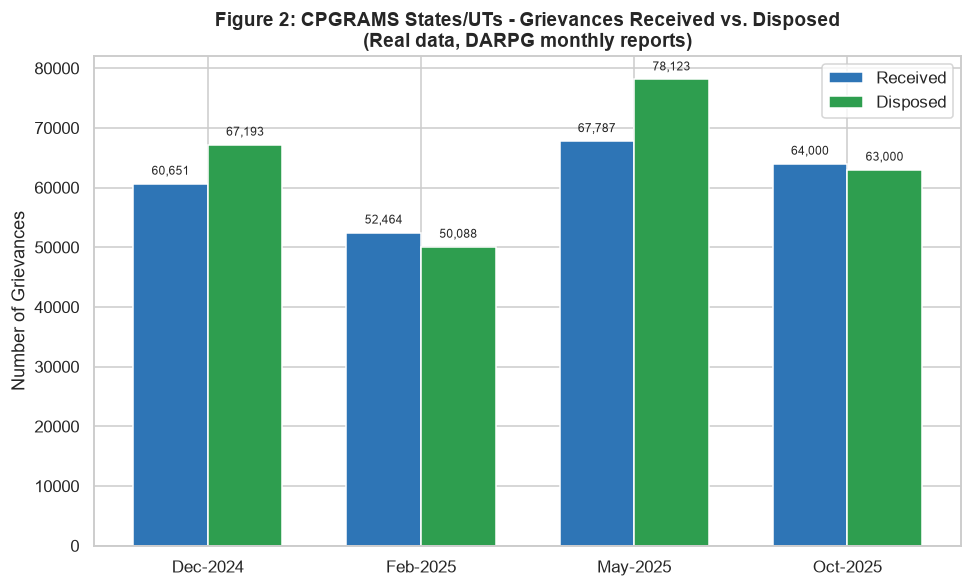

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(states_monthly))
width = 0.35
ax.bar(x - width/2, states_monthly["Received"], width, label="Received", color="#2E75B6")
ax.bar(x + width/2, states_monthly["Disposed"], width, label="Disposed", color="#2E9E4F")
ax.set_xticks(x)
ax.set_xticklabels(states_monthly["Month"])
ax.set_title("Figure 2: CPGRAMS States/UTs - Grievances Received vs. Disposed\n(Real data, DARPG monthly reports)",
             fontsize=12.5, fontweight="bold")
ax.set_ylabel("Number of Grievances")
ax.legend()
for i, (rec, disp) in enumerate(zip(states_monthly["Received"], states_monthly["Disposed"])):
    ax.text(i - width/2, rec + 1500, f"{rec:,.0f}", ha="center", fontsize=8)
    ax.text(i + width/2, disp + 1500, f"{disp:,.0f}", ha="center", fontsize=8)
plt.tight_layout()
# plt.savefig("w6_chart2_received_vs_disposed.png", dpi=150, bbox_inches="tight")
plt.show()


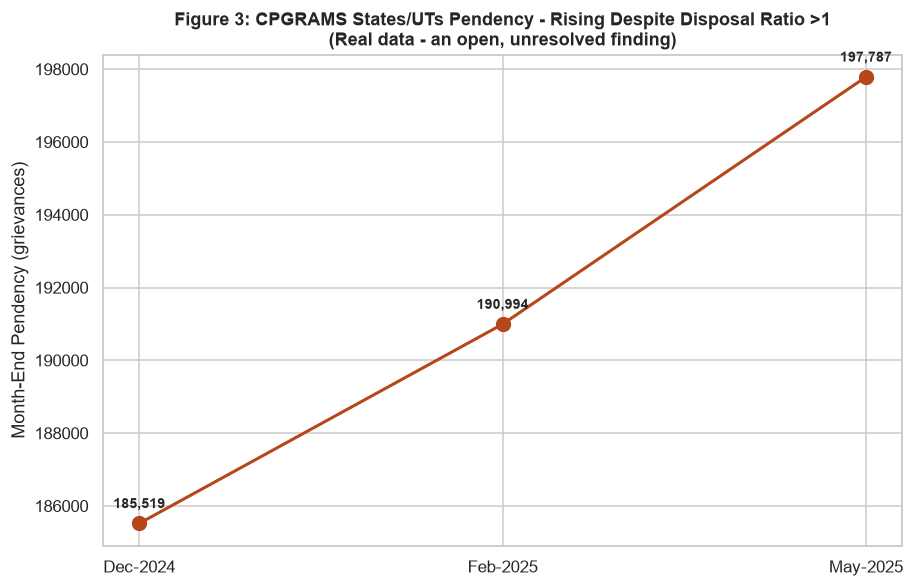

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(pend["Month"], pend["Pendency"], marker="o", markersize=9, linewidth=2, color="#B5471B")
for _, row in pend.iterrows():
    ax.annotate(f"{row['Pendency']:,.0f}", (row["Month"], row["Pendency"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, fontweight="bold")
ax.set_title("Figure 3: CPGRAMS States/UTs Pendency - Rising Despite Disposal Ratio >1\n(Real data - an open, unresolved finding)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Month-End Pendency (grievances)")
plt.tight_layout()
# plt.savefig("w6_chart3_pendency_trend.png", dpi=150, bbox_inches="tight")
plt.show()


**The open finding:** the disposal-to-received ratio averages 1.05 across the three confirmed
months — States/UTs disposed of slightly *more* grievances than they received. Yet pendency still
*rose* 6.6% (185,519 to 197,787) over the same window. This is reported as a genuine, unresolved
puzzle rather than forced into a tidy explanation: it likely reflects either a backlog of older,
harder-to-close cases accumulating outside the simple received/disposed accounting, or a timing
lag between when a grievance is logged and when it enters the disposal count — this notebook does
not have enough information to determine which.

## 4. Export Case Study Summary

In [9]:
summary = pd.DataFrame([
    {"Metric": "Avg disposal time trend (2021->2026)", "Value": "32 days -> 13 days", "Change": "-59%"},
    {"Metric": "Disposal-time regression slope", "Value": f"{slope*12:.2f} days/year", "Change": f"r={r_value:.3f}, p={p_value:.3f}"},
    {"Metric": "Mean States/UTs disposal ratio", "Value": f"{states_monthly['DisposalRatio'].mean():.3f}", "Change": "Disposed/Received, 3 exact months"},
    {"Metric": "States/UTs pendency (confirmed months)", "Value": "185,519 -> 197,787", "Change": "+6.6%"},
])
summary.to_csv("cpgrams_case_study_summary.csv", index=False)
summary


,Metric,Value,Change
0,Avg disposal time trend (2021->2026),32 days -> 13 days,-59%
1,Disposal-time regression slope,-2.70 days/year,"r=-0.830, p=0.021"
2,Mean States/UTs disposal ratio,1.050,"Disposed/Received, 3 exact months"
3,States/UTs pendency (confirmed months),"185,519 -> 197,787",+6.6%


## 5. Interactive Dashboard

Builds a self-contained HTML dashboard (KPI cards + interactive Plotly charts) summarising the
cross-week synthesis and this case study — fully offline.


In [10]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import plotly.offline as pyo

plotly_js = pyo.get_plotlyjs()

fig_disposal = px.scatter(
    disposal_time, x="PeriodIndex", y="AvgDisposalDays", text="Period",
    title="Grievance Disposal Time Trend (Central Ministries)",
    color_discrete_sequence=["#1F4E79"]
)
fig_disposal.update_traces(textposition="top center", marker=dict(size=11))
fig_disposal.add_trace(go.Scatter(
    x=[0, 69], y=[intercept, intercept + slope * 69],
    mode="lines", name="Trend", line=dict(color="#B5471B", dash="dash")
))
fig_disposal.update_layout(height=420, margin=dict(l=10, r=10, t=50, b=10), showlegend=False,
                            xaxis_title="Time Index (months since Jan 2021)", yaxis_title="Avg Disposal Time (days)")

fig_throughput = px.bar(
    states_monthly, x="Month", y=["Received", "Disposed"], barmode="group",
    title="States/UTs: Grievances Received vs. Disposed",
    color_discrete_sequence=["#2E75B6", "#2E9E4F"]
)
fig_throughput.update_layout(height=420, margin=dict(l=10, r=10, t=50, b=10), legend_title="")

fig_pendency = px.line(
    pend, x="Month", y="Pendency", markers=True,
    title="States/UTs Pendency - Rising Despite Disposal Ratio > 1",
    color_discrete_sequence=["#B5471B"]
)
fig_pendency.update_layout(height=420, margin=dict(l=10, r=10, t=50, b=10))

print("Dashboard charts built.")


Dashboard charts built.


In [11]:
charts_html = {
    "disposal": pio.to_html(fig_disposal, include_plotlyjs=False, full_html=False),
    "throughput": pio.to_html(fig_throughput, include_plotlyjs=False, full_html=False),
    "pendency": pio.to_html(fig_pendency, include_plotlyjs=False, full_html=False),
}

kpi_cards = f"""
<div class="kpi-grid">
  <div class="kpi-card"><div class="kpi-label">Weeks Synthesized</div><div class="kpi-value">5</div></div>
  <div class="kpi-card"><div class="kpi-label">Resources Used</div><div class="kpi-value">3</div></div>
  <div class="kpi-card"><div class="kpi-label">Disposal Time Change</div><div class="kpi-value">32 to 13 days</div></div>
  <div class="kpi-card"><div class="kpi-label">Disposal Trend</div><div class="kpi-value">r={r_value:.2f}</div></div>
  <div class="kpi-card"><div class="kpi-label">Mean Disposal Ratio</div><div class="kpi-value">{states_monthly["DisposalRatio"].mean():.2f}</div></div>
  <div class="kpi-card"><div class="kpi-label">Pendency Change</div><div class="kpi-value">+6.6%</div></div>
</div>
"""

html_template = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Digital Transformation - Final Evaluation Dashboard</title>
<script>{plotly_js}</script>
<style>
  :root {{ --navy: #1F4E79; --teal: #2E9E8F; --grey: #595959; --bg: #F5F7FA; }}
  * {{ box-sizing: border-box; }}
  body {{ font-family: -apple-system, "Segoe UI", Roboto, Helvetica, Arial, sans-serif; margin: 0; background: var(--bg); color: #1f1f1f; }}
  header {{ background: linear-gradient(90deg, var(--navy), var(--teal)); color: white; padding: 28px 36px; }}
  header h1 {{ margin: 0 0 4px 0; font-size: 26px; }}
  header p {{ margin: 0; opacity: 0.9; font-size: 14px; }}
  .container {{ max-width: 1300px; margin: 0 auto; padding: 24px 20px 60px; }}
  .kpi-grid {{ display: grid; grid-template-columns: repeat(6, 1fr); gap: 14px; margin-bottom: 26px; }}
  .kpi-card {{ background: white; border-radius: 10px; padding: 16px 10px; box-shadow: 0 1px 4px rgba(0,0,0,0.08); text-align: center; }}
  .kpi-label {{ font-size: 11px; color: var(--grey); text-transform: uppercase; letter-spacing: 0.03em; margin-bottom: 6px; }}
  .kpi-value {{ font-size: 20px; font-weight: 700; color: var(--navy); }}
  .chart-grid {{ display: grid; grid-template-columns: repeat(2, 1fr); gap: 18px; }}
  .chart-card {{ background: white; border-radius: 10px; padding: 6px 10px 10px; box-shadow: 0 1px 4px rgba(0,0,0,0.08); }}
  .chart-card.full {{ grid-column: 1 / -1; }}
  .note {{ background: #FFF7E6; border-left: 4px solid #C98A1F; padding: 12px 16px; border-radius: 6px; margin-bottom: 20px; font-size: 13px; color: #5c4a1f; }}
  footer {{ text-align: center; color: var(--grey); font-size: 12px; padding: 20px; }}
  @media (max-width: 900px) {{
    .kpi-grid {{ grid-template-columns: repeat(2, 1fr); }}
    .chart-grid {{ grid-template-columns: 1fr; }}
  }}
</style>
</head>
<body>
<header>
  <h1>Digital Transformation - Final Evaluation Dashboard</h1>
  <p>Week 6 Case Study: CPGRAMS / DARPG (Government of India) - a third, independent resource from UIDAI and NPCI</p>
</header>
<div class="container">
  {kpi_cards}
  <div class="note">This dashboard covers only the Week 6 cross-domain validation case study (CPGRAMS). See Weeks 1-5 dashboards for the UIDAI- and UPI-based analyses this report synthesizes.</div>
  <div class="chart-grid">
    <div class="chart-card full">{charts_html['disposal']}</div>
    <div class="chart-card">{charts_html['throughput']}</div>
    <div class="chart-card">{charts_html['pendency']}</div>
  </div>
  <footer>Data source: DARPG / CPGRAMS (Government of India) &middot; Built with pandas, scipy &amp; Plotly</footer>
</div>
</body>
</html>
"""

with open("digital_transformation_dashboard.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("Dashboard saved to digital_transformation_dashboard.html")


Dashboard saved to digital_transformation_dashboard.html


## 6. Key Takeaway

This case study's purpose was never to analyse CPGRAMS as thoroughly as UIDAI (Weeks 1-4) or UPI
(Week 5) — with only 7 and 4 data points respectively, that depth of analysis isn't supported by
the available data. Its purpose was narrower and more targeted: **does the internship's way of
working — real data first, explicit flags wherever simulation or interpolation was unavoidable,
and honest reporting of findings that don't fit a tidy narrative — transfer to a resource the
rest of the internship never touched?**

The answer is yes: a real declining disposal-time trend was found and cautiously extrapolated
(with the same caveats Week 5 applied to UPI), and a genuine, unresolved puzzle (rising pendency
despite a healthy disposal ratio) was reported as open rather than forced into a false conclusion.
